In [3]:
import sys

sys.path.append(r'c:/Users/sebas/MalariaProject/src')

In [4]:
import numpy as np

from src.lattice_v4 import LatticeSOS_v4
from src.params_v4 import KMCParams_v4
from src.bkl_v4 import KMC_BKL_v4

In [ ]:


# Crear la red y dejarla plana
lat = LatticeSOS_v4(size=16, seed=123)
lat.initialize(mode="flat")

# Parámetros anisotrópicos (x/y distintos)
params = KMCParams_v4(
    K0_plus=2.214,
    E_pb_over_kT_x=2.0,
    E_pb_over_kT_y=1.2,
    phi_over_kT=5.0,
    delta_x=0.4,
    delta_y=0.7,
    V=1.0,
    C_eq=1e3,
    fixed_sigma=None,
    S_floor=-5.0,
    S_ceil=8.0,
    # Puedes omitir estos factores; se ignorarán si use_solvent=False
    solvent_ads_factor=0.3,
    solvent_des_factor=2.0,
    solvent_mig_factor=0.5,
)

# Motor con anisotropía ON y solvente OFF
kmc = KMC_BKL_v4(
    lattice=lat,
    params=params,
    N_bulk0=2000,
    rng_seed=7,
    time_scale=50.0,
    n_seeds=5,
    debug=False,
    constant_concentration=False,
    use_anisotropy=True,
    use_solvent=False,
    enable_desorption=True,
    enable_migration=True,
)

# Ejecutar y guardar snapshots
snapshot_times = np.linspace(0.0, 15.0, 15).tolist()
snaps, stats = kmc.run(t_end=15.0, snapshot_times=snapshot_times, max_events=30000)

# Resumen rápido
print("Eventos:", stats["event_counts"])
print("Tiempo final:", stats["total_time"])

Eventos: {'adsorption': 366, 'desorption': 344, 'migration': 728, 'incorporation': 0}
Tiempo final: 15.00290800852331


🧩 Usando último snapshot: t=15.000


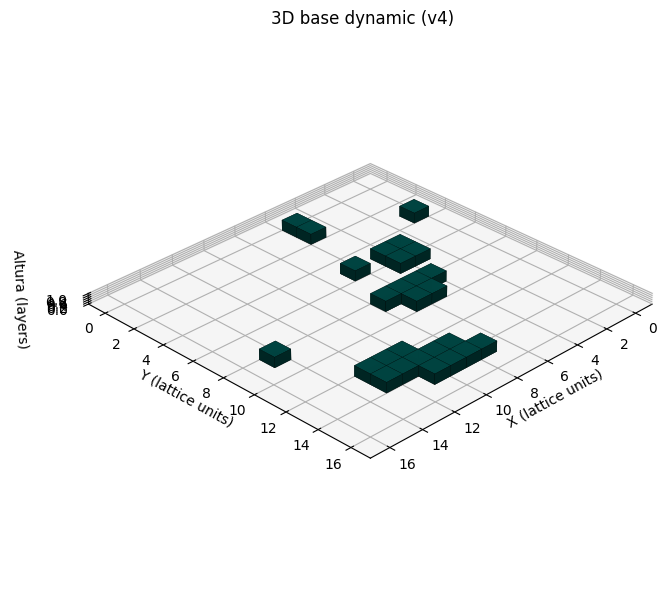

FileNotFoundError: [Errno 2] No such file or directory: 'results/3d_base_dynamic.gif'

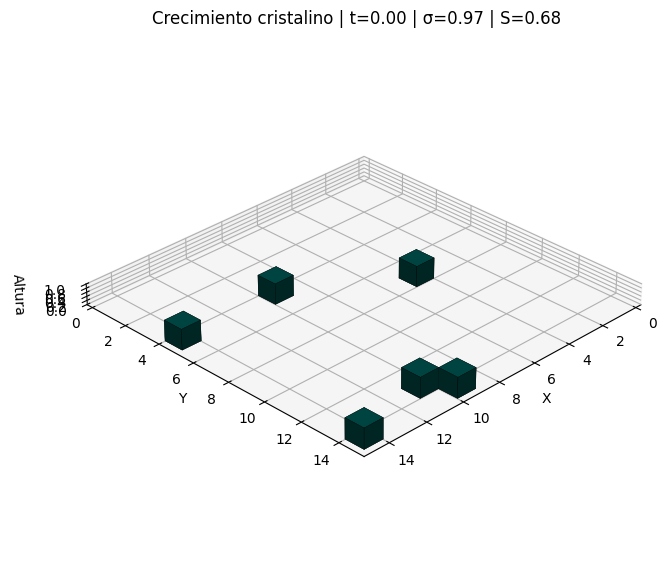

In [7]:
from src.plotter_v2 import Plotter_v2
# Visualizacion 3D y gif
plotter = Plotter_v2(kmc)
plotter.plot_crystal_3d(mode="voxel", snapshots=snaps, title="3D base dynamic (v4)")
gif_path = "results/3d_base_dynamic.gif"
plotter.crystal_growth_gif(
    snaps,
    gif_path,
    mode="voxel",
    fps=8,
    interval_ms=200,
    dpi=120,
    every_n=1
)

0.0
0.460211265957598
0.8100915042739736
0.9932070476518712
1.2310180754086744
1.3560509372071627
1.481531537785739
1.612171099335505
1.7738890342172544
1.930061710462336
1.9967535525178777
2.123558421294161
2.1740277758891957
2.254468135545758
2.318205332307518
2.3844145798839853
2.4497353952560013
2.518361203757235
2.5835041614124887
2.6426812233700536
2.707276004983784
2.7797932273028114
2.8594273972968125
2.943588542042152
2.993464124306762
3.0292904727374252
3.090233265447069
3.151046726777706
3.2030659976960174
3.263458662245175
3.332368892031427
3.3969445426001412
3.4677734119136163
3.5208069901079497
3.626184814952723
3.6836857371424476
3.7714160690782252
3.860257501493783
3.925702311220642
3.979852336301998
4.066967218008884
4.188280898581499
4.29730202809621
4.4039400843224845
4.563824372105054
4.749942732073597
4.97702385048135


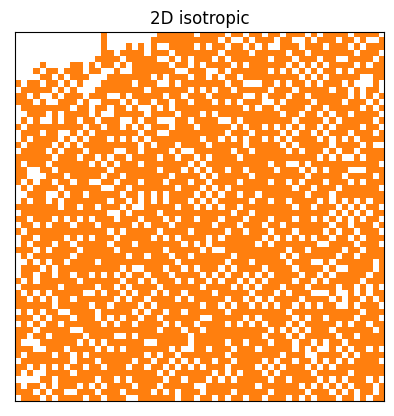

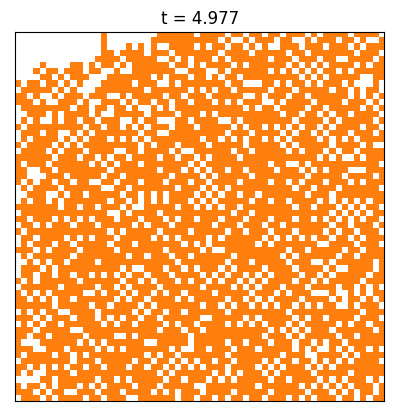

In [9]:
# Ejemplo 1: 2D isotropico (sin anisotropia)
# Nota: ejecuta el notebook con el root del proyecto como directorio de trabajo.
from src.model2D import Params2D, KMC2D, KMC2DVisualizer

# Configurar y ejecutar el modelo base
params = Params2D()
kmc = KMC2D(params, seed=1)
times, cover, snapshots = kmc.run_until(tmax=5.0, snapshot_every=0.5, store_snapshots=True)

# Si no hubo snapshots, usar el estado actual
if not snapshots:
    snapshots = [(kmc.t, kmc.grid.copy())]

# Visualizacion de la red y gif
viz = KMC2DVisualizer()
viz.plot_snapshot(snapshots[-1], title='2D isotropic', show=True)
gif_path = r"C:\Users\sebas\MalariaProject\results\modelos_gifs\2d_isotropic.gif"
viz.save_gif(snapshots, gif_path, fps=6, dpi=120)

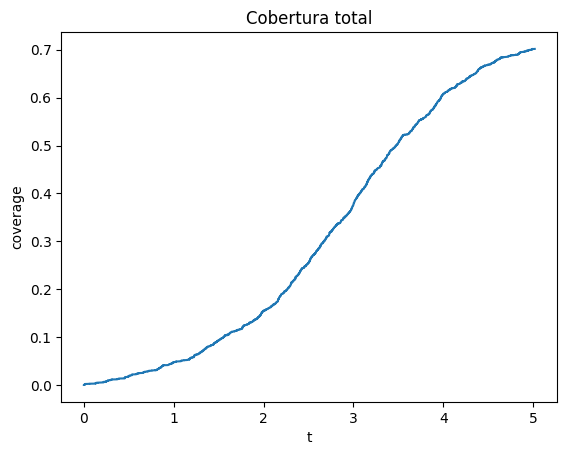

In [9]:
import matplotlib.pyplot as plt
# Graficar la cobertura total en el tiempo
plt.figure()
plt.plot(times, cover)
plt.xlabel("t")
plt.ylabel("coverage")
plt.title("Cobertura total")
plt.show()

0.0
1.586626250844616
2.1695561589032204
2.5183554061292748
2.9088663405093556
3.211564995833928
3.503411743292074
3.8148153829024536
4.02492997082248
4.3234036785916246
4.517976331561766
4.682197579250117
4.87405119811992
0.0
0.9761428359849887
1.3674023224072762
1.6654782066804508
1.9254408769043017
2.11881260951367
2.28360515920185
2.468391197760004
2.6616450951863606
2.8672840748576727
2.9569891076806973
3.070426502775221
3.2157050023402696
3.3190221609247255
3.4293331984212734
3.5547695024603563
3.645142860512352
3.7093269935907713
3.7868490718810195
3.8661352863180523
3.9314112973668203
4.014427149073926
4.107149103442626
4.211926111986724
4.27268880875392
4.348098399547508
4.403609288483129
4.472931616314291
4.527378679423134
4.60833175057466
4.66277987954491
4.763486953376108
4.839269426116951
4.893544692675246
4.993428973868953


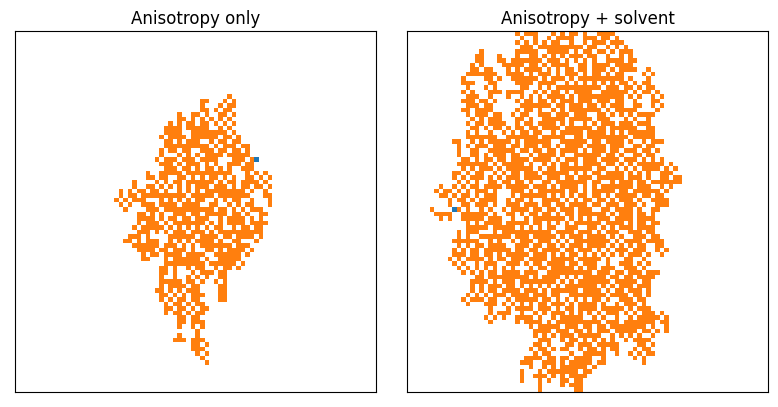

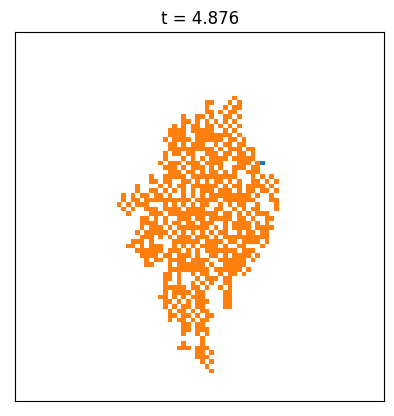

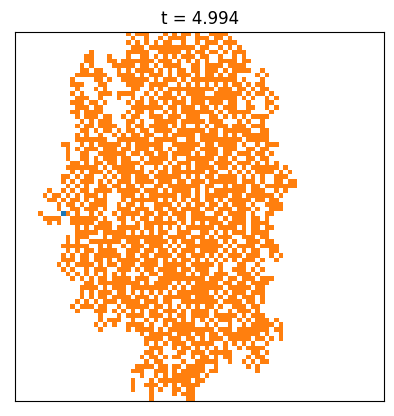

In [10]:
# Ejemplo 2: 2D anisotropia + solvente (comparativo)
# Nota: ejecuta el notebook con el root del proyecto como directorio de trabajo.
import matplotlib.pyplot as plt
from src.model2D_v3 import Params2D as Params2D_v3, KMC2D, KMC2DVisualizer

# Parametros anisotropicos de referencia (sin solvente)
params_ref = Params2D_v3(
    Jad_x=0.04, Jad_y=0.08,
    Jinc_x=0.01, Jinc_y=0.02,
    Jmove_x=0.03, Jmove_y=0.05
)

# Parametros con anisotropia y efectos de solvente
params_sol = Params2D_v3(
    Jad_x=0.04, Jad_y=0.08,
    Jinc_x=0.01, Jinc_y=0.02,
    Jmove_x=0.03, Jmove_y=0.05,
    solvent_ads_factor=1.7,
    solvent_des_factor=0.3,
    solvent_diff_factor=0.6,
    solvent_inc_factor=0.8
)

# Ejecutar ambos casos
kmc_ref = KMC2D(params_ref, seed=2)
times_ref, cover_ref, snapshots_ref = kmc_ref.run_until(tmax=5.0, snapshot_every=0.5, store_snapshots=True)

kmc_sol = KMC2D(params_sol, seed=3)
times_sol, cover_sol, snapshots_sol = kmc_sol.run_until(tmax=5.0, snapshot_every=0.5, store_snapshots=True)

# Si no hubo snapshots, usar el estado actual
if not snapshots_ref:
    snapshots_ref = [(kmc_ref.t, kmc_ref.grid.copy())]
if not snapshots_sol:
    snapshots_sol = [(kmc_sol.t, kmc_sol.grid.copy())]

# Visualizacion comparativa de la red
viz = KMC2DVisualizer()
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
viz.plot_snapshot(snapshots_ref[-1], ax=axes[0], title='Anisotropy only', show=False)
viz.plot_snapshot(snapshots_sol[-1], ax=axes[1], title='Anisotropy + solvent', show=False)
plt.tight_layout()
plt.show()

# Guardar gifs de ambos casos
gif_path_ref = r"C:\Users\sebas\MalariaProject\results\modelos_gifs\2d_anisotropic_ref.gif"
viz.save_gif(snapshots_ref, gif_path_ref, fps=6, dpi=120)
gif_path_sol = r"C:\Users\sebas\MalariaProject\results\modelos_gifs\2d_anisotropic_solvent.gif"
viz.save_gif(snapshots_sol, gif_path_sol, fps=6, dpi=120)

0.0
1.157275691662514
1.5645415895040127
1.806350816185908
2.0103081191350283
2.229540330768965
2.4504770700608027
2.6030828577887073
2.6913919475284627
2.806445197137626
2.9164097411147445
3.0228152111363187
3.158747221564678
3.284995035794203
3.375982942752553
3.4647546771997217
3.5932311006756654
3.718985038401099
3.792933715851269
3.8844894989880276
3.9737361004182654
4.06926678247909
4.143221323026536
4.20087993447565
4.269009811070265
4.330579028653323
4.399963891203767
4.499517760469041
4.58044946867502
4.655472761361949
4.732051769749047
4.817495423496444
4.89912786909013
4.969335318177196


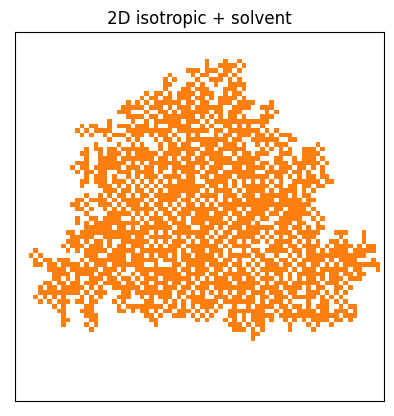

t_final=5.002, coverage_final=0.302


In [11]:
# Ejemplo 2b: 2D isotropico con solvente
from src.model2D_v3 import Params2D as Params2D_v3, KMC2D, KMC2DVisualizer

# Parametros isotropicos con solvente
params_iso_sol = Params2D_v3(
    Jad_x=0.04, Jad_y=0.04,
    Jinc_x=0.01, Jinc_y=0.01,
    Jdes_x=0.05, Jdes_y=0.05,
    Jmove_x=0.03, Jmove_y=0.03,
    solvent_ads_factor=0.7,
    solvent_des_factor=0.3,
    solvent_diff_factor=0.6,
    solvent_inc_factor=0.8,
)

# Ejecutar caso isotropico con solvente
kmc_iso_sol = KMC2D(params_iso_sol, seed=4, use_anisotropy=False, use_solvent=True)
times_iso_sol, cover_iso_sol, snapshots_iso_sol = kmc_iso_sol.run_until(
    tmax=5.0, snapshot_every=0.5, store_snapshots=True
)
if not snapshots_iso_sol:
    snapshots_iso_sol = [(kmc_iso_sol.t, kmc_iso_sol.grid.copy())]

# Visualizacion
viz = KMC2DVisualizer()
viz.plot_snapshot(snapshots_iso_sol[-1], title="2D isotropic + solvent", show=True)
print(f"t_final={kmc_iso_sol.t:.3f}, coverage_final={cover_iso_sol[-1] if len(cover_iso_sol) else 0.0:.3f}")

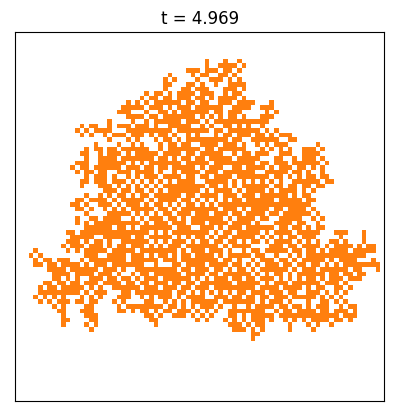

In [14]:
gif_path_iso_sol = r"C:\Users\sebas\MalariaProject\results\modelos_gifs\2d_isotropic_solvent.gif"
viz.save_gif(snapshots_iso_sol, gif_path_iso_sol, fps=6, dpi=120)

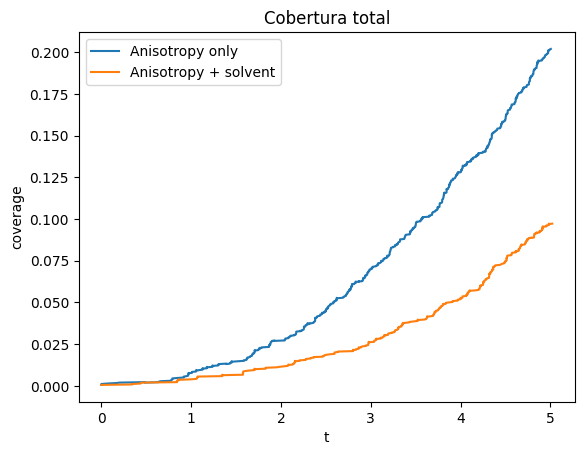

In [8]:
import matplotlib.pyplot as plt
# Graficar la cobertura total en el tiempo
plt.figure()
plt.plot(times_ref, cover_ref, label='Anisotropy only')
plt.plot(times_sol, cover_sol, label='Anisotropy + solvent')
plt.xlabel("t")
plt.ylabel("coverage")
plt.title("Cobertura total")
plt.legend()
plt.show()

In [ ]:
# Ejemplo 3: 3D base con sobresaturacion dinamica (v4)
# Nota: ejecuta el notebook con el root del proyecto como directorio de trabajo.
import numpy as np
from src.lattice_v4 import LatticeSOS_v4
from src.params_v4 import KMCParams_v4
from src.bkl_v4 import KMC_BKL_v4
from src.plotter_v2 import Plotter_v2

# Configurar red y parametros base (dinamico)
lat = LatticeSOS_v4(size=16, seed=100)
lat.initialize(mode="flat")

params = KMCParams_v4(
    K0_plus=1e4,
    E_pb_over_kT_x=2.0,
    E_pb_over_kT_y=2.0,
    phi_over_kT=5.0,
    delta_x=0.4,
    delta_y=0.4,
    V=1.0,
    C_eq=1e3,
    fixed_sigma=None,
    S_floor=-5.0,
    S_ceil=8.0,
)

kmc = KMC_BKL_v4(
    lattice=lat,
    params=params,
    N_bulk0=20000,
    rng_seed=123,
    time_scale=1.0,
    n_seeds=10,
    debug=False,
    constant_concentration=False
)

snapshot_times = np.linspace(0.2, 3.0, 12).tolist()
snaps, stats = kmc.run(t_end=3.0, snapshot_times=snapshot_times, max_events=30000)

# Si no hubo snapshots, usar el estado actual
if not snaps:
    snaps = [(kmc.t, kmc.lat.heights.copy(), 0.0)]

from src.plotter_v2 import Plotter_v2
# Visualizacion 3D y gif
plotter = Plotter_v2(kmc)
plotter.plot_crystal_3d(mode="voxel", snapshots=snaps, title="3D base dynamic (v4)")
gif_path = "results/3d_base_dynamic.gif"
plotter.crystal_growth_gif(
    snaps,
    gif_path,
    mode="surface",
    fps=8,
    interval_ms=200,
    dpi=120,
    every_n=1
)

In [ ]:
# Ejemplo 4: 3D base con sobresaturacion constante (v4)
# Nota: ejecuta el notebook con el root del proyecto como directorio de trabajo.
import numpy as np
from src.lattice_v4 import LatticeSOS_v4
from src.params_v4 import KMCParams_v4
from src.bkl_v4 import KMC_BKL_v4
from src.plotter_v2 import Plotter_v2

# Configurar red y parametros con sigma fijo
lat = LatticeSOS_v4(size=16, seed=200)
lat.initialize(mode="flat")

params = KMCParams_v4(
    K0_plus=0.211,
    E_pb_over_kT_x=0.48,
    E_pb_over_kT_y=0.48,
    phi_over_kT=3.76,
    delta_x=0.63,
    delta_y=0.63,
    V=1.0,
    C_eq=15.0,
    fixed_sigma=4.0,
    S_floor=-5.0,
    S_ceil=8.0,
)

kmc = KMC_BKL_v4(
    lattice=lat,
    params=params,
    N_bulk0=100000,
    rng_seed=456,
    time_scale=1.0,
    n_seeds=10,
    debug=False,
    constant_concentration=True
)

snapshot_times = np.linspace(0.2, 3.0, 12).tolist()
snaps, stats = kmc.run(t_end=3.0, snapshot_times=snapshot_times, max_events=30000)

# Si no hubo snapshots, usar el estado actual
if not snaps:
    snaps = [(kmc.t, kmc.lat.heights.copy(), 0.0)]

# Visualizacion 3D y gif
plotter = Plotter_v2(kmc)
plotter.plot_crystal_3d(mode="voxel", snapshots=snaps, title="3D base fixed sigma (v4)")
gif_path = "results/3d_base_fixed_sigma.gif"
plotter.crystal_growth_gif(
    snaps,
    gif_path,
    mode="surface",
    fps=8,
    interval_ms=200,
    dpi=120,
    every_n=1
)

🧩 Usando último snapshot: t=10.000


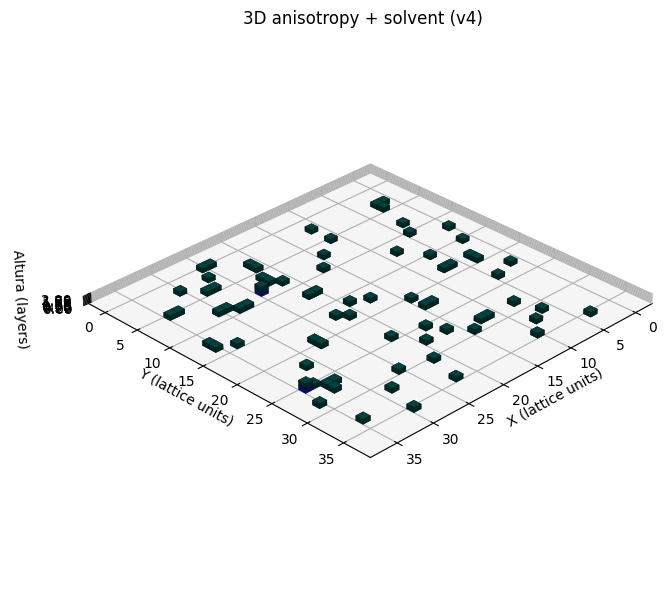

💾 GIF guardado en: C:\Users\sebas\MalariaProject\results\modelos_gifs\3d_anisotropic.gif


In [11]:
# Ejemplo 5: 3D con anisotropia y efectos de solvente (v4)
# Nota: ejecuta el notebook con el root del proyecto como directorio de trabajo.
import numpy as np
from src.lattice_v4 import LatticeSOS_v4
from src.params_v4 import KMCParams_v4
from src.bkl_v4 import KMC_BKL_v4
from src.plotter_v2 import Plotter_v2

# Configurar red y parametros anisotropicos con solvente
lat = LatticeSOS_v4(size=36, seed=300)
lat.initialize(mode="flat")

# params = KMCParams_v4(
#     K0_plus=0.211,
#     E_pb_over_kT_x=0.6,
#     E_pb_over_kT_y=0.2,
#     phi_over_kT=3.5,
#     delta_x=0.5,
#     delta_y=0.8,
#     V=1.0,
#     C_eq=15.0,
#     fixed_sigma=4.0,
#     S_floor=-5.0,
#     S_ceil=8.0,
#     solvent_ads_factor=0.8,
#     solvent_des_factor=1.2,
#     solvent_mig_factor=0.7
# )

# Parametros con anisotropia fuerte en x
params = KMCParams_v4(
    K0_plus=0.214,
    E_pb_over_kT_x=2.4,  # mas fuerte en x
    E_pb_over_kT_y=0.8,  # mas debil en y
    phi_over_kT=5.0,
    delta_x=0.6,         # adsorcion preferente en x
    delta_y=0.2,         # adsorcion menor en y
    V=1.0,
    C_eq=1e3,
    fixed_sigma=5.0,
    S_floor=-5.0,
    S_ceil=8.0,
    # Solvente opcional: reduce migracion para fijar la forma
    solvent_mig_factor=0.5,
)

kmc = KMC_BKL_v4(
    lattice=lat,
    params=params,
    N_bulk0=100000,
    rng_seed=789,
    time_scale=100,
    n_seeds=100,
    debug=False,
    constant_concentration=True
)

snapshot_times = np.linspace(0.2, 10.0, 12).tolist()
snaps, stats = kmc.run(t_end=10.0, snapshot_times=snapshot_times)

# Si no hubo snapshots, usar el estado actual
if not snaps:
    snaps = [(kmc.t, kmc.lat.heights.copy(), 0.0)]

# Visualizacion 3D y gif
plotter = Plotter_v2(kmc)
plotter.plot_crystal_3d(mode="voxel", snapshots=snaps, title="3D anisotropy + solvent (v4)")
gif_path = r"C:\Users\sebas\MalariaProject\results\modelos_gifs\3d_anisotropic.gif"
plotter.crystal_growth_gif(
    snaps,
    gif_path,
    mode="voxel",
    fps=8,
    interval_ms=200,
    dpi=120,
    every_n=1
)

In [17]:
# Ejemplo 6: 3D anisotropico tipo aguja (elongacion en x)
import numpy as np
from src.lattice_v4 import LatticeSOS_v4
from src.params_v4 import KMCParams_v4
from src.bkl_v4 import KMC_BKL_v4
from src.plotter_v2 import Plotter_v2

# Red mas grande y semilla central unica para isla centrada
lat = LatticeSOS_v4(size=28, seed=500)
lat.initialize(mode="flat")
lat.inc_height((lat.nx // 2, lat.ny // 2), 1)

# Anisotropia fuerte: enlaces y adsorcion favorecidos en x
params = KMCParams_v4(
    K0_plus=2.14,
    E_pb_over_kT_x=3.0,  # enlaces fuertes en x
    E_pb_over_kT_y=0.6,  # enlaces debiles en y
    phi_over_kT=4.0,
    delta_x=1.0,         # adsorcion preferente en x
    delta_y=0.15,
    V=1.0,
    C_eq=1e3,
    fixed_sigma=6.0,
    S_floor=-5.0,
    S_ceil=8.0,
 )

# Reducir migracion para preservar la morfologia alargada
kmc = KMC_BKL_v4(
    lattice=lat,
    params=params,
    N_bulk0=100000,
    rng_seed=501,
    time_scale=25.0,
    n_seeds=0,
    debug=False,
    constant_concentration=True,
    use_anisotropy=True,
    use_solvent=False,
    enable_migration=False,
 )

# Ejecutar y visualizar
snapshot_times = np.linspace(0.2, 6.0, 12).tolist()
snaps, stats = kmc.run(t_end=6.0, snapshot_times=snapshot_times, max_events=80000)
if not snaps:
    snaps = [(kmc.t, kmc.lat.heights.copy(), 0.0)]
print("event_counts=", stats["event_counts"])

plotter = Plotter_v2(kmc)
plotter.plot_crystal_3d(mode="voxel", snapshots=snaps, title="3D aguja (anisotropia en x)")

KeyboardInterrupt: 

event_counts= {'adsorption': 1834, 'desorption': 99, 'migration': 127, 'incorporation': 0}
🧩 Usando último snapshot: t=30.000


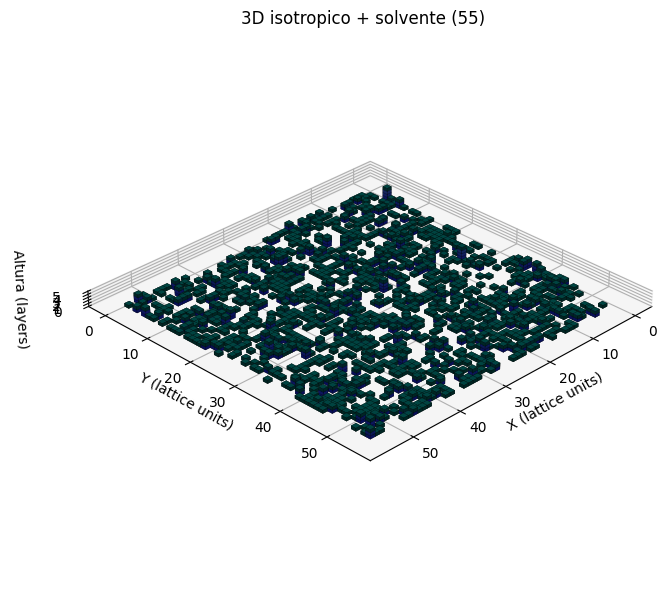

In [24]:
# Ejemplo 7: 3D isotropico con solvente (red 55)
import numpy as np
from src.lattice_v4 import LatticeSOS_v4
from src.params_v4 import KMCParams_v4
from src.bkl_v4 import KMC_BKL_v4
from src.plotter_v2 import Plotter_v2

# Red 55x55 y superficie plana
lat = LatticeSOS_v4(size=55, seed=600)
lat.initialize(mode="flat")

# Parametros isotropicos (x=y) con solvente
params = KMCParams_v4(
    K0_plus=0.214,
    E_pb_over_kT_x=0.5,
    E_pb_over_kT_y=0.5,
    phi_over_kT=0.95,
    delta_x=0.4,
    delta_y=0.4,
    V=1.0,
    C_eq=1e3,
    fixed_sigma=4.0,
    S_floor=-5.0,
    S_ceil=8.0,
    solvent_ads_factor=0.8,
    solvent_des_factor=0.6,
    solvent_mig_factor=0.7,
)

# Motor isotropico usando use_anisotropy=False
kmc = KMC_BKL_v4(
    lattice=lat,
    params=params,
    N_bulk0=80000,
    rng_seed=601,
    time_scale=50.0,
    n_seeds=8,
    debug=False,
    constant_concentration=True,
    use_anisotropy=False,
    use_solvent=True,
)

# Ejecutar y visualizar
snapshot_times = np.linspace(0.0, 30.0, 30).tolist()
snaps, stats = kmc.run(t_end=30.0, snapshot_times=snapshot_times, max_events=40000)
if not snaps:
    snaps = [(kmc.t, kmc.lat.heights.copy(), 0.0)]
print("event_counts=", stats["event_counts"])

plotter = Plotter_v2(kmc)
plotter.plot_crystal_3d(mode="voxel", snapshots=snaps, title="3D isotropico + solvente (55)")

In [10]:
# Ejemplo 8: 3D anisotropico con solvente (red 55)
import numpy as np
from src.lattice_v4 import LatticeSOS_v4
from src.params_v4 import KMCParams_v4
from src.bkl_v4 import KMC_BKL_v4
from src.plotter_v2 import Plotter_v2

# Red 55x55 y superficie plana
lat = LatticeSOS_v4(size=55, seed=610)
lat.initialize(mode="flat")

# Parametros anisotropicos con solvente
params = KMCParams_v4(
    K0_plus=0.214,
    E_pb_over_kT_x=3.22,
    E_pb_over_kT_y=0.80,
    phi_over_kT=0.95,
    delta_x=1,
    delta_y=0.16,
    V=1.0,
    C_eq=1e3,
    fixed_sigma=4.0,
    S_floor=-5.0,
    S_ceil=8.0,
    solvent_ads_factor=0.8,
    solvent_des_factor=0.6,
    solvent_mig_factor=0.7,
)

# Motor anisotropico con solvente
kmc = KMC_BKL_v4(
    lattice=lat,
    params=params,
    N_bulk0=80000,
    rng_seed=611,
    time_scale=50.0,
    n_seeds=8,
    debug=False,
    constant_concentration=True,
    use_anisotropy=True,
    use_solvent=True,
)

# Ejecutar y visualizar
snapshot_times = np.linspace(0.0, 30.0, 30).tolist()
snaps, stats = kmc.run(t_end=30.0, snapshot_times=snapshot_times, max_events=40000)
if not snaps:
    snaps = [(kmc.t, kmc.lat.heights.copy(), 0.0)]
print("event_counts=", stats["event_counts"])

plotter = Plotter_v2(kmc)
plotter.plot_crystal_3d(mode="voxel", snapshots=snaps, title="3D anisotropico + solvente (55)")

TypeError: __init__() got an unexpected keyword argument 'use_anisotropy'

# **Observables**

In [14]:
import numpy as np
from typing import Dict, List, Optional, Sequence, Tuple

# Utilidades base para medir observables prioritarios (Malaria.md)
from src.utils_v2 import HEMIN, STEP, VECINOS, in_bounds

Mask = np.ndarray
Component = List[Tuple[int, int]]

def occupied_mask_2d(grid: np.ndarray) -> Mask:
    # Huella ocupada del modelo 2D (HEMIN/STEP)
    return np.isin(grid, (HEMIN, STEP))

def occupied_mask_3d(heights: np.ndarray) -> Mask:
    # Proyeccion 2D del SOS 3D
    return heights > 0

def bounding_box(mask: Mask) -> Optional[Tuple[int, int, int, int]]:
    # Caja envolvente del cluster
    coords = np.argwhere(mask)
    if coords.size == 0:
        return None
    min_i, min_j = coords.min(axis=0)
    max_i, max_j = coords.max(axis=0)
    return int(min_i), int(max_i), int(min_j), int(max_j)

def extent_lengths_from_mask(mask: Mask) -> Tuple[int, int]:
    # Extensiones en x/y desde la caja envolvente
    bbox = bounding_box(mask)
    if bbox is None:
        return 0, 0
    min_i, max_i, min_j, max_j = bbox
    return max_i - min_i + 1, max_j - min_j + 1

def connected_components(mask: Mask) -> List[Component]:
    # Componentes 4-conectadas usando vecindad del core
    visited = np.zeros(mask.shape, dtype=bool)
    components: List[Component] = []
    nx, ny = mask.shape

    for i in range(nx):
        for j in range(ny):
            if not mask[i, j] or visited[i, j]:
                continue

            queue: List[Tuple[int, int]] = [(i, j)]
            visited[i, j] = True
            component: Component = []
            q_idx = 0

            # BFS simple sin usar deque (solo listas)
            while q_idx < len(queue):
                ci, cj = queue[q_idx]
                q_idx += 1
                component.append((ci, cj))
                for di, dj in VECINOS:
                    ni, nj = ci + di, cj + dj
                    if in_bounds(ni, nj, nx, ny) and mask[ni, nj] and not visited[ni, nj]:
                        visited[ni, nj] = True
                        queue.append((ni, nj))

            components.append(component)

    return components

def component_mask(shape: Tuple[int, int], component: Component) -> Mask:
    # Mascara booleana para un componente
    mask = np.zeros(shape, dtype=bool)
    for i, j in component:
        mask[i, j] = True
    return mask

def largest_component_mask(mask: Mask) -> Mask:
    # Mantener solo el componente mas grande
    components = connected_components(mask)
    if not components:
        return np.zeros(mask.shape, dtype=bool)
    return component_mask(mask.shape, max(components, key=len))

def aspect_ratio_from_mask(mask: Mask, use_largest_component: bool = True) -> float:
    # Razon de aspecto L/W del cluster
    target = largest_component_mask(mask) if use_largest_component else mask
    lx, ly = extent_lengths_from_mask(target)
    if lx == 0 or ly == 0:
        return 0.0
    return float(max(lx, ly)) / float(min(lx, ly))

def principal_axis_angle_deg(mask: Mask, use_largest_component: bool = True) -> Optional[float]:
    # Orientacion del eje mayor via PCA
    target = largest_component_mask(mask) if use_largest_component else mask
    coords = np.argwhere(target).astype(float)
    if coords.shape[0] < 2:
        return None
    coords -= coords.mean(axis=0)
    cov = np.cov(coords, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    main_vec = eigvecs[:, int(np.argmax(eigvals))]
    # 0 deg apunta al eje y/columnas; 90 deg al eje x/filas
    return float(np.degrees(np.arctan2(main_vec[0], main_vec[1])))

def growth_rate_linear(times: Sequence[float], values: Sequence[float]) -> float:
    # Pendiente lineal como proxy de tasa global
    t = np.asarray(times, dtype=float)
    y = np.asarray(values, dtype=float)
    valid = np.isfinite(t) & np.isfinite(y)
    if np.count_nonzero(valid) < 2:
        return 0.0
    return float(np.polyfit(t[valid], y[valid], deg=1)[0])

def anisotropy_from_snapshots(mask0: Mask, t0: float, mask1: Mask, t1: float) -> Tuple[float, float, float]:
    # Velocidades de avance vx/vy desde cambio de extension
    dt = max(float(t1 - t0), 1e-12)
    lx0, ly0 = extent_lengths_from_mask(largest_component_mask(mask0))
    lx1, ly1 = extent_lengths_from_mask(largest_component_mask(mask1))
    vx = (lx1 - lx0) / dt
    vy = (ly1 - ly0) / dt
    ratio = vx / vy if abs(vy) > 1e-12 else np.inf
    return float(vx), float(vy), float(ratio)

In [15]:
# Observables 2D prioritarios: tasa, morfologia y anisotropia
def summarize_2d_observables_top5(
    times: Sequence[float],
    cover_total: Sequence[float],
    snapshots: Sequence[Tuple[float, np.ndarray]],
) -> Dict[str, object]:
    # Observables top-5 segun Malaria.md (validacion inmediata)
    if not snapshots:
        raise ValueError("2D snapshots requeridos. Ejecuta run_until con store_snapshots=True.")

    t0, grid0 = snapshots[0]
    t_last, grid_last = snapshots[-1]
    mask0 = occupied_mask_2d(grid0)
    mask_last = occupied_mask_2d(grid_last)
    vx, vy, v_ratio = anisotropy_from_snapshots(mask0, t0, mask_last, t_last)

    return {
        "growth_rate_cover": growth_rate_linear(times, cover_total),
        "final_coverage": float(cover_total[-1]) if len(cover_total) else 0.0,
        "aspect_ratio": aspect_ratio_from_mask(mask_last),
        "principal_axis_deg": principal_axis_angle_deg(mask_last),
        "vx": vx,
        "vy": vy,
        "vx_over_vy": v_ratio,
    }

In [16]:
# Observables 3D prioritarios: tasa, morfologia, anisotropia, rugosidad y eventos
def surface_roughness(heights: np.ndarray) -> float:
    # Rugosidad como desviacion estandar
    return float(np.std(heights))

def height_histogram(heights: np.ndarray) -> Dict[int, float]:
    # Histograma normalizado de alturas enteras
    values, counts = np.unique(heights.astype(int), return_counts=True)
    total = float(heights.size)
    return {int(v): float(c) / total for v, c in zip(values, counts)}

def event_balance(stats: Dict[str, object]) -> Dict[str, float]:
    # Balance de eventos normalizado
    counts = dict(stats.get("event_counts", {}))
    total = float(sum(counts.values()))
    if total <= 0.0:
        return {str(k): 0.0 for k in counts}
    return {str(k): float(v) / total for k, v in counts.items()}

def summarize_3d_observables_top5(
    snaps: Sequence[Tuple[float, np.ndarray, float]],
    stats: Dict[str, object],
) -> Dict[str, object]:
    # Observables top-5 segun Malaria.md (validacion inmediata)
    if not snaps:
        raise ValueError("3D snapshots requeridos. Pasa snapshot_times a run().")

    height_history = np.asarray(stats.get("height_history", []), dtype=float)
    if height_history.size and height_history.ndim == 2 and height_history.shape[1] >= 2:
        growth_rate = growth_rate_linear(height_history[:, 0], height_history[:, 1])
    else:
        growth_rate = 0.0

    t0, h0, _ = snaps[0]
    t_last, h_last, _ = snaps[-1]
    mask0 = occupied_mask_3d(h0)
    mask_last = occupied_mask_3d(h_last)
    vx, vy, v_ratio = anisotropy_from_snapshots(mask0, t0, mask_last, t_last)

    return {
        "growth_rate_height": growth_rate,
        "aspect_ratio": aspect_ratio_from_mask(mask_last),
        "principal_axis_deg": principal_axis_angle_deg(mask_last),
        "vx": vx,
        "vy": vy,
        "vx_over_vy": v_ratio,
        "roughness": surface_roughness(h_last),
        "height_histogram": height_histogram(h_last),
        "event_balance": event_balance(stats),
    }

In [13]:
# Calcular observables usando resultados existentes del notebook
try:
    obs2d = summarize_2d_observables_top5(times, cover, snapshots)
    print("2D observables top5:")
    for key, value in obs2d.items():
        print(f"  {key}: {value}")
except NameError as exc:
    # Mensaje claro si faltan variables 2D
    print("No encuentro variables 2D (times, cover, snapshots). Ejecuta los ejemplos 2D antes.")
    print(exc)

try:
    obs3d = summarize_3d_observables_top5(snaps, stats)
    print("3D observables top5:")
    for key, value in obs3d.items():
        print(f"  {key}: {value}")
except NameError as exc:
    # Mensaje claro si faltan variables 3D
    print("No encuentro variables 3D (snaps, stats). Ejecuta un ejemplo 3D antes.")
    print(exc)

2D observables top5:
  growth_rate_cover: 0.1847349345674492
  final_coverage: 0.7016666666666667
  aspect_ratio: 1.0
  principal_axis_deg: 41.25474942410831
  vx: 11.854474009480619
  vy: 11.653550721184336
  vx_over_vy: 1.017241379310345
3D observables top5:
  growth_rate_height: 0.005209720655389257
  aspect_ratio: 1.0
  principal_axis_deg: 45.0
  vx: 0.1020408163265306
  vy: 0.1020408163265306
  vx_over_vy: 1.0
  roughness: 0.24423216090944405
  height_histogram: {0: 0.941358024691358, 1: 0.05709876543209876, 2: 0.0015432098765432098}
  event_balance: {'adsorption': 0.4502487562189055, 'desorption': 0.2562189054726368, 'migration': 0.2935323383084577, 'incorporation': 0.0}
